# Customer Churn Prediction with TabNet

This notebook trains a production-style TabNet classifier for a customer churn prediction task using the provided train/validation/test CSV files. The workflow includes:

- Data loading and validation
- Feature/target separation
- Model training with early stopping
- Evaluation using classification metrics and ROC-AUC
- Model interpretation via feature importances
- Saving the trained model artifact

The dataset is expected to contain a binary target column named `Churn` and all other columns as model features.

In [2]:
# Install the required dependency if it is not already available.
# This is safe to rerun in a notebook environment.
# %pip install -q pytorch-tabnet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from pytorch_tabnet.tab_model import TabNetClassifier

print(f"PyTorch version: {torch.__version__}")
print("TabNet imported successfully.")

PyTorch version: 2.7.1+cu118
TabNet imported successfully.


In [ ]:
# Load the train/validation/test datasets.
train_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\train_churn_dataset.csv")
val_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\val_churn_dataset.csv")
test_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\test_churn_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Columns: {list(train_df.columns)}")
print("\nFirst rows of train data:")
train_df.head()

Train shape: (314599, 13)
Validation shape: (67414, 13)
Test shape: (67415, 13)
Columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly', 'Churn']

First rows of train data:


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Churn
0,-0.194805,-1.763854,-0.438373,2.053966,-0.022554,0.839526,0.175954,1.0,0.0,0.0,0.0,0.0,1
1,0.366541,1.195766,-0.670829,0.759068,-0.262646,-0.291292,-1.336418,1.0,0.0,0.0,0.0,1.0,1
2,-1.157113,0.383321,1.072594,-0.859555,0.697723,1.195727,-1.336418,1.0,0.0,1.0,0.0,0.0,0
3,0.927888,-0.719283,-1.251970,1.406517,-1.223015,-1.354388,-1.452754,1.0,0.0,1.0,0.0,0.0,1
4,1.248657,-1.705822,-1.251970,1.406517,-0.022554,-1.337830,1.455654,1.0,0.0,1.0,0.0,1.0,1


In [4]:
# Validate target column and identify feature columns.
TARGET = "Churn"
feature_names = [col for col in train_df.columns if col != TARGET]

assert TARGET in train_df.columns and TARGET in val_df.columns and TARGET in test_df.columns

X_train = train_df[feature_names].astype(np.float32)
y_train = train_df[TARGET].astype(np.int64)

X_val = val_df[feature_names].astype(np.float32)
y_val = val_df[TARGET].astype(np.int64)

X_test = test_df[feature_names].astype(np.float32)
y_test = test_df[TARGET].astype(np.int64)

print(f"Training features: {X_train.shape}")
print(f"Validation features: {X_val.shape}")
print(f"Test features: {X_test.shape}")
print(f"Positive rate in train set: {y_train.mean():.4f}")
print(f"Positive rate in validation set: {y_val.mean():.4f}")
print(f"Positive rate in test set: {y_test.mean():.4f}")

train_label_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
print("\nTrain label distribution:")
print(train_label_dist)

Training features: (314599, 12)
Validation features: (67414, 12)
Test features: (67415, 12)
Positive rate in train set: 0.5000
Positive rate in validation set: 0.5000
Positive rate in test set: 0.5000

Train label distribution:
Churn
0    0.499998
1    0.500002
Name: proportion, dtype: float64


In [10]:
# Configure a TabNet classifier optimized for binary classification.
# TabNet requires NumPy arrays or Pandas DataFrames, and works well with tabular data like this churn dataset.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-4),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 10, "gamma": 0.9},
    mask_type="entmax",
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.3,
    lambda_sparse=1e-3,
    seed=42,
    verbose=1,
    device_name=DEVICE,
)

print(f"Training TabNet on device: {DEVICE}")

Training TabNet on device: cuda


In [12]:
import time
t0 = time.time()
model.fit(
    X_train.values[:5000], y_train.values[:5000],
    eval_set=[(X_val.values[:1000], y_val.values[:1000])],
    max_epochs=2,
    batch_size=512,
    virtual_batch_size=128,
)
print("took", time.time() - t0, "seconds")

epoch 0  | loss: 1.04048 | val_0_auc: 0.82032 |  0:00:00s
epoch 1  | loss: 0.43073 | val_0_auc: 0.88423 |  0:00:00s
Stop training because you reached max_epochs = 2 with best_epoch = 1 and best_val_0_auc = 0.88423
took 0.9110028743743896 seconds


In [ ]:
print("Training started...")

# Fit the model.
# We use the validation set for early stopping and model selection.
model.fit(
    X_train.values,
    y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    eval_metric=["auc", "balanced_accuracy"],
    max_epochs=30,
    patience=5,
    batch_size=2048,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

print("Training complete.")

Training started...
epoch 0  | loss: 0.33093 | val_0_auc: 0.94475 | val_0_balanced_accuracy: 0.91512 |  0:00:16s
epoch 1  | loss: 0.24072 | val_0_auc: 0.9466  | val_0_balanced_accuracy: 0.91838 |  0:00:39s
epoch 2  | loss: 0.23555 | val_0_auc: 0.94824 | val_0_balanced_accuracy: 0.92057 |  0:00:59s
epoch 3  | loss: 0.23209 | val_0_auc: 0.94735 | val_0_balanced_accuracy: 0.91838 |  0:01:27s
epoch 4  | loss: 0.23157 | val_0_auc: 0.94747 | val_0_balanced_accuracy: 0.92211 |  0:01:59s
epoch 5  | loss: 0.22945 | val_0_auc: 0.94683 | val_0_balanced_accuracy: 0.91838 |  0:02:32s
epoch 6  | loss: 0.23024 | val_0_auc: 0.94823 | val_0_balanced_accuracy: 0.92065 |  0:03:05s
epoch 7  | loss: 0.22723 | val_0_auc: 0.94883 | val_0_balanced_accuracy: 0.92183 |  0:03:35s
epoch 8  | loss: 0.22616 | val_0_auc: 0.94868 | val_0_balanced_accuracy: 0.9215  |  0:03:56s
epoch 9  | loss: 0.22403 | val_0_auc: 0.94881 | val_0_balanced_accuracy: 0.92015 |  0:04:15s
epoch 10 | loss: 0.22409 | val_0_auc: 0.94785 | va

AttributeError: 'TabNetClassifier' object has no attribute 'best_epoch_'

In [ ]:
print(f"Best epoch: {model.best_epoch_}")
print(f"Best validation AUC: {model.best_cost_:.4f}")

AttributeError: 'TabNetClassifier' object has no attribute 'best_cost_'

In [16]:
# Generate predictions and probabilities for evaluation.
val_prob = model.predict_proba(X_val.values)[:, 1]
test_prob = model.predict_proba(X_test.values)[:, 1]

val_pred = (val_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

print("Validation metrics:")
print(f"  AUC: {roc_auc_score(y_val.values, val_prob):.4f}")
print(f"  Accuracy: {accuracy_score(y_val.values, val_pred):.4f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_val.values, val_pred):.4f}")

print("\nTest metrics:")
print(f"  AUC: {roc_auc_score(y_test.values, test_prob):.4f}")
print(f"  Accuracy: {accuracy_score(y_test.values, test_pred):.4f}")
print(f"  Precision: {precision_score(y_test.values, test_pred):.4f}")
print(f"  Recall: {recall_score(y_test.values, test_pred):.4f}")
print(f"  F1-score: {f1_score(y_test.values, test_pred):.4f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test.values, test_pred):.4f}")

Validation metrics:
  AUC: 0.9506
  Accuracy: 0.9246
  Balanced Accuracy: 0.9246

Test metrics:
  AUC: 0.9511
  Accuracy: 0.9253
  Precision: 0.8747
  Recall: 0.9928
  F1-score: 0.9300
  Balanced Accuracy: 0.9253


              precision    recall  f1-score   support

    No Churn     0.9917    0.8577    0.9199     33708
       Churn     0.8747    0.9928    0.9300     33707

    accuracy                         0.9253     67415
   macro avg     0.9332    0.9253    0.9249     67415
weighted avg     0.9332    0.9253    0.9249     67415



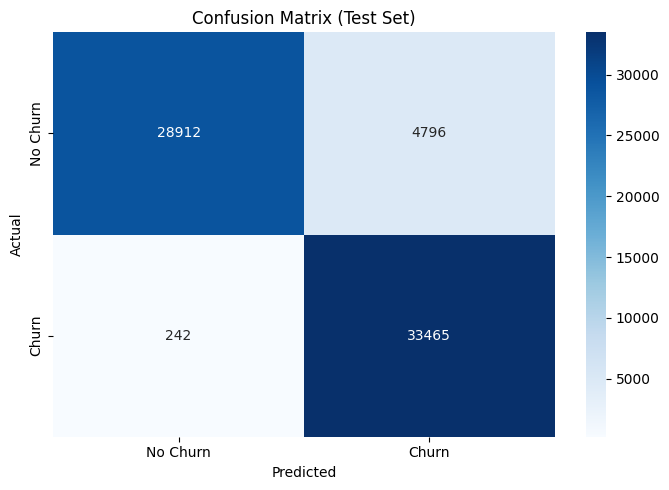

In [17]:
# Full classification report.
report = classification_report(
    y_test.values,
    test_pred,
    target_names=["No Churn", "Churn"],
    digits=4,
)
print(report)

cm = confusion_matrix(y_test.values, test_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

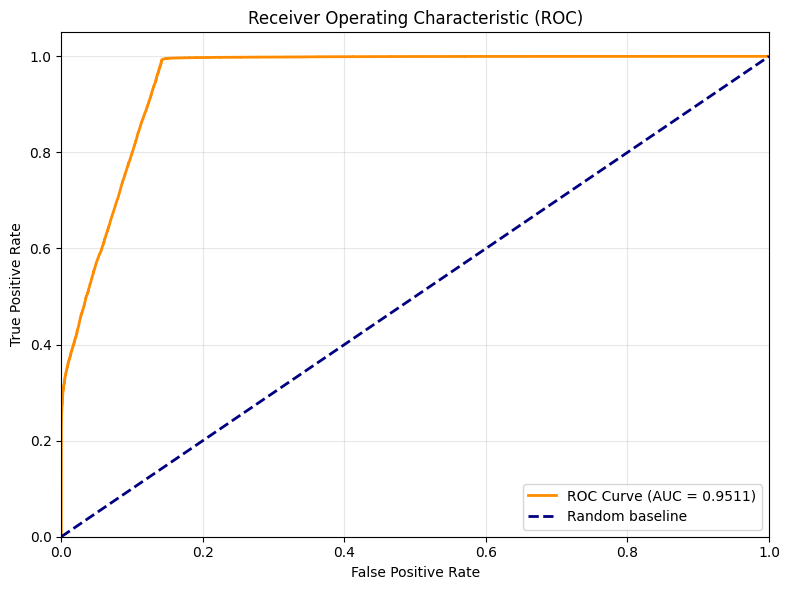

In [18]:
# ROC curve for the test set.
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test.values, test_prob)
roc_auc = roc_auc_score(y_test.values, test_prob)

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Plot training progress and validation metrics if available.
history = getattr(model, "history", {})
if isinstance(history, dict):
    loss = history.get("loss")
    val_loss = history.get("val_0_loss")

    if loss is not None:
        plt.figure(figsize=(10, 5))
        plt.plot(loss, label="Training loss", color="tab:blue")
        if val_loss is not None:
            plt.plot(val_loss, label="Validation loss", color="tab:orange")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("TabNet history is not available for plotting.")

TabNet history is not available for plotting.


In [20]:
# Feature importance summary from TabNet.
feature_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 most important features:")
print(feature_importance.head(10).to_string())

Top 10 most important features:
Gender_Male                   0.254109
Usage Frequency               0.155010
Support Calls                 0.133711
Age                           0.091461
Tenure                        0.081632
Subscription Type_Standard    0.080828
Contract Length_Monthly       0.055071
Total Spend                   0.046470
Payment Delay                 0.044972
Contract Length_Quarterly     0.035457


In [21]:
# Save the trained model for later deployment or inference.
model_path = r"C:\Users\User\ODL_Labs\Assignment\tabnet_churn_model"
model.save_model(model_path)
print(f"Model saved to: {model_path}")

Successfully saved model at C:\Users\User\ODL_Labs\Assignment\tabnet_churn_model.zip
Model saved to: C:\Users\User\ODL_Labs\Assignment\tabnet_churn_model


## Summary

This TabNet workflow is designed for reliable churn prediction on tabular customer data. It follows a realistic production pattern:

1. Load and validate the data split.
2. Train a TabNet classifier with early stopping.
3. Evaluate using AUC, accuracy, precision, recall, F1, and balanced accuracy.
4. Inspect model performance using ROC and confusion matrix plots.
5. Save the trained model artifact for downstream deployment.

For deployment, the saved model can be reloaded with `TabNetClassifier.load_model(model_path)`.